In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [2]:
pip install "numpy<2"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# 1) ĐỌC DỮ LIỆU
df = pd.read_excel("../data/dl_KLB.xlsx")
df.columns = df.columns.str.strip()

# Bỏ các cột không dùng
df = df.drop(columns=["Tên", "CCCD"], errors="ignore")

# Biến mục tiêu: gợi ý sản phẩm vay
target_col = "Kết quả khoản vay đã vay"

# Loại bỏ các dòng từ chối để bài toán chỉ còn gợi ý sản phẩm
df_model = df[~df[target_col].astype(str).str.startswith("Từ chối")].copy()

print("Kích thước dữ liệu gốc:", df.shape)
print("Kích thước dữ liệu dùng train:", df_model.shape)
print("Số lớp sản phẩm vay:", df_model[target_col].nunique())
print(df_model[target_col].value_counts())

NameError: name 'pd' is not defined

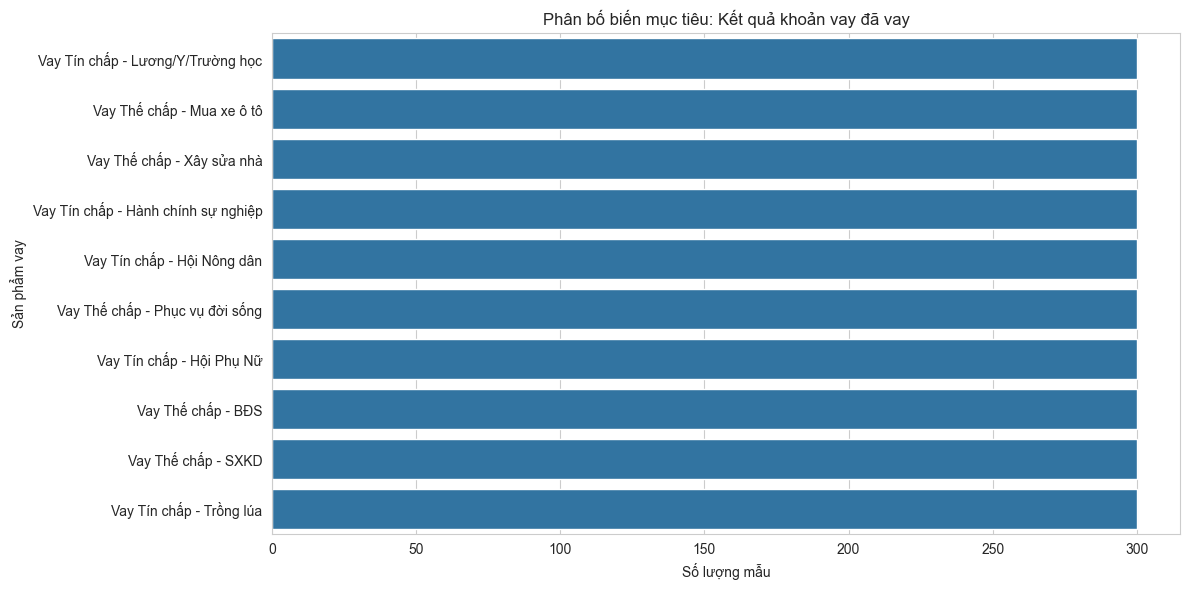

In [4]:
# 2) BIỂU ĐỒ PHÂN BỐ BIẾN MỤC TIÊU
plt.figure(figsize=(12, 6))
order = df_model[target_col].value_counts().index
sns.countplot(data=df_model, y=target_col, order=order)
plt.title("Phân bố biến mục tiêu: Kết quả khoản vay đã vay")
plt.xlabel("Số lượng mẫu")
plt.ylabel("Sản phẩm vay")
plt.tight_layout()
plt.show()

In [ ]:
# 3) CHỌN BIẾN ĐẦU VÀO
feature_cols = [
    "Giới tính",
    "Nhóm tuổi",
    "Có TSBĐ không?",
    "Hình thức vay",
    "Mục đích sử dụng",
    "Thu nhập",
    "Số lượng khoản vay đang hoạt động?",
    "Tổng số tiền trả nợ các khoản vay khác",
    "Số tiền muốn vay",
    "Giá trị BĐS",
    "Thời gian vay (tháng)",
    "Lịch sử nợ xấu tín dụng trong 05 năm gần nhất",
    "Lịch sử chậm thanh toán thẻ tín dụng trong 03 năm gần nhất",
    "Nợ cần chú ý trong vòng 12 tháng gần nhất",
    "Kết quả DTI",
    "Kết quả LTV"
]

feature_cols = [c for c in feature_cols if c in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

print("Danh sách biến đầu vào:")
print(feature_cols)

Danh sách biến đầu vào:
['Giới tính', 'Nhóm tuổi', 'Có TSBĐ không?', 'Hình thức vay', 'Mục đích sử dụng', 'Thu nhập', 'Số lượng khoản vay đang hoạt động?', 'Tổng số tiền trả nợ các khoản vay khác', 'Số tiền muốn vay', 'Giá trị BĐS', 'Thời gian vay (tháng)', 'Lịch sử nợ xấu tín dụng trong 05 năm gần nhất', 'Lịch sử chậm thanh toán thẻ tín dụng trong 03 năm gần nhất', 'Nợ cần chú ý trong vòng 12 tháng gần nhất', 'Kết quả DTI', 'Kết quả LTV']


In [ ]:
# 4) CHIA NUMERIC / CATEGORICAL
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numeric_transformer, numeric_cols)
    ]
)

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

In [2]:
# 5) CHIA TRAIN / TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

NameError: name 'train_test_split' is not defined

In [ ]:
# 6) HUẤN LUYỆN 2 MÔ HÌNH + SO SÁNH
results = {}
trained_models = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    }

    trained_models[name] = {
        "pipe": pipe,
        "y_pred": y_pred
    }

    print("="*80)
    print(name)
    print("Accuracy:", results[name]["Accuracy"])
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).T.sort_values("F1_macro", ascending=False)
best_model_name = results_df.index[0]
best_pipe = trained_models[best_model_name]["pipe"]
best_y_pred = trained_models[best_model_name]["y_pred"]

print("Kết quả so sánh:")
print(results_df)
print("Model tốt nhất:", best_model_name)

Decision Tree
Accuracy: 0.7235294117647059
                                     precision    recall  f1-score   support

                 Vay Thế chấp - BĐS       0.97      0.97      0.97        40
         Vay Thế chấp - Mua xe ô tô       0.97      0.95      0.96        39
    Vay Thế chấp - Phục vụ đời sống       0.97      1.00      0.99        37
                Vay Thế chấp - SXKD       0.95      0.90      0.93        41
         Vay Thế chấp - Xây sửa nhà       0.92      0.97      0.94        35
Vay Tín chấp - Hành chính sự nghiệp       0.27      1.00      0.43        31
        Vay Tín chấp - Hội Nông dân       0.00      0.00      0.00        30
          Vay Tín chấp - Hội Phụ Nữ       0.91      1.00      0.95        31
  Vay Tín chấp - Lương/Y/Trường học       0.00      0.00      0.00        26
           Vay Tín chấp - Trồng lúa       0.00      0.00      0.00        30

                           accuracy                           0.72       340
                          macro

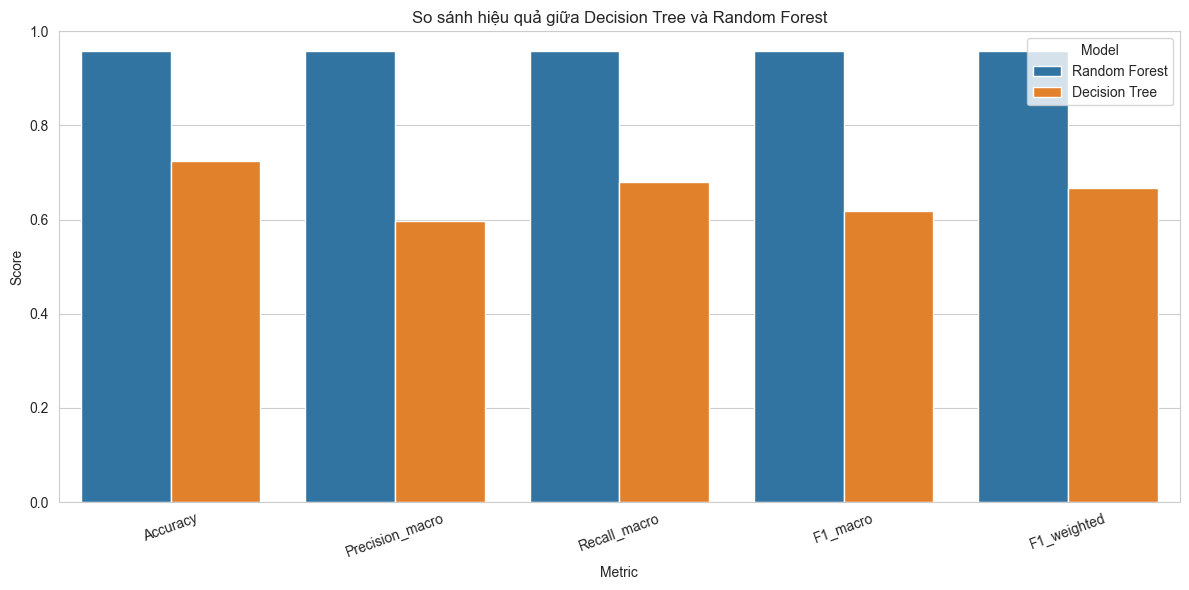

In [ ]:
# 7) BIỂU ĐỒ SO SÁNH CÁC CHỈ SỐ GIỮA 2 MÔ HÌNH
plot_df = results_df.reset_index().rename(columns={"index": "Model"})
plot_df = plot_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted"],
                       var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("So sánh hiệu quả giữa Decision Tree và Random Forest")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

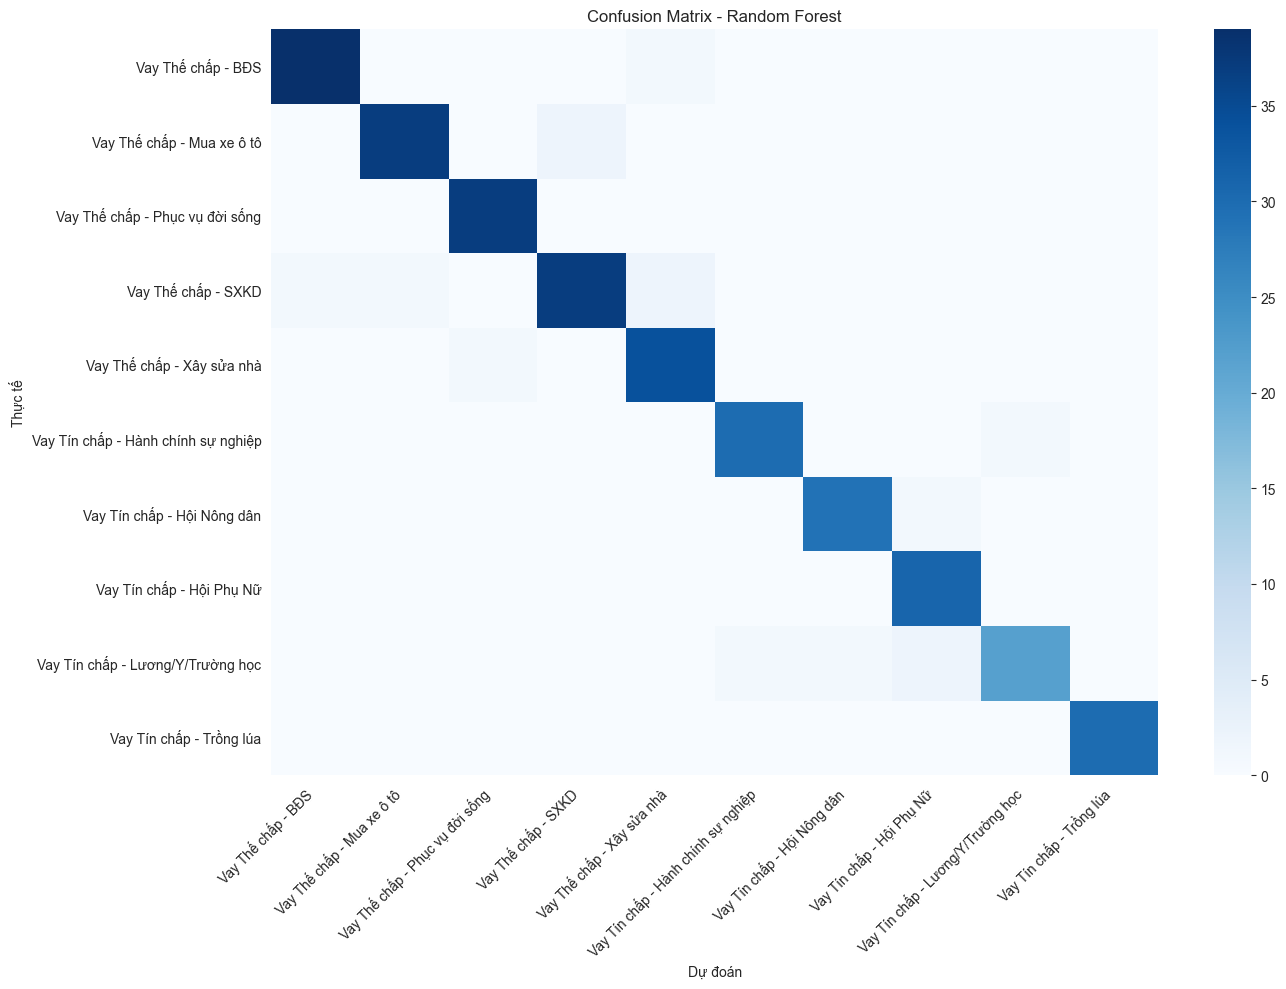

In [ ]:
# 8) CONFUSION MATRIX CHO MÔ HÌNH TỐT NHẤT
cm = confusion_matrix(y_test, best_y_pred, labels=best_pipe.named_steps["model"].classes_)
labels = best_pipe.named_steps["model"].classes_

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

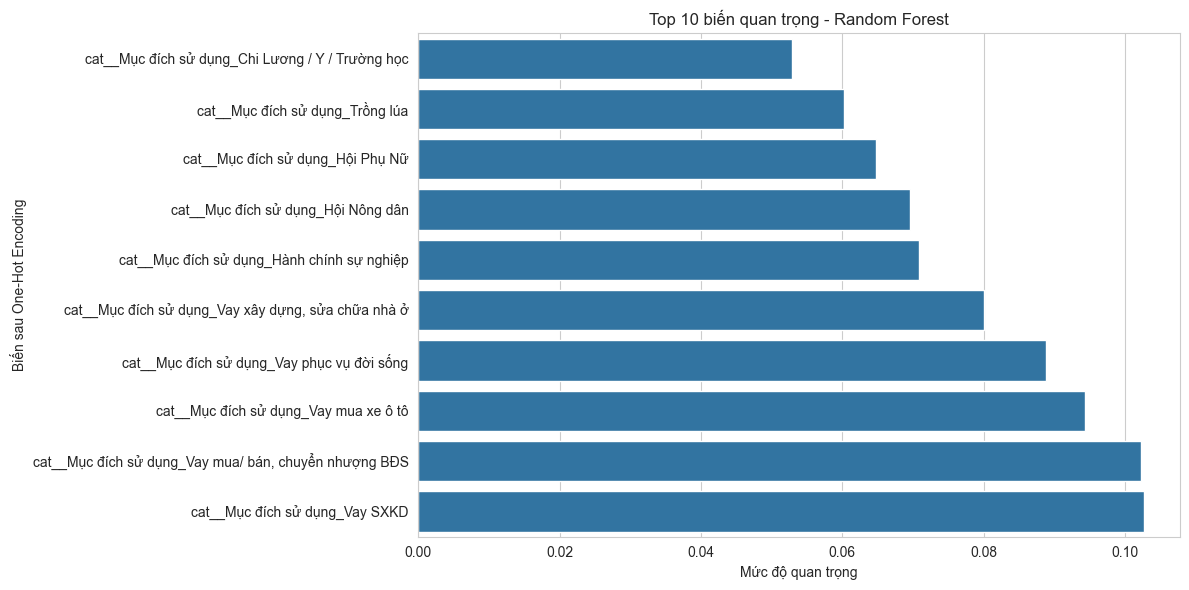

                                                 Biến  Mức độ quan trọng
14                     cat__Mục đích sử dụng_Vay SXKD           0.102666
16  cat__Mục đích sử dụng_Vay mua/ bán, chuyển như...           0.102282
15              cat__Mục đích sử dụng_Vay mua xe ô tô           0.094356
17         cat__Mục đích sử dụng_Vay phục vụ đời sống           0.088789
18  cat__Mục đích sử dụng_Vay xây dựng, sửa chữa n...           0.080055
10         cat__Mục đích sử dụng_Hành chính sự nghiệp           0.070827
11                 cat__Mục đích sử dụng_Hội Nông dân           0.069590
12                   cat__Mục đích sử dụng_Hội Phụ Nữ           0.064791
13                    cat__Mục đích sử dụng_Trồng lúa           0.060296
9    cat__Mục đích sử dụng_Chi Lương / Y / Trường học           0.052953
32                                   num__Kết quả LTV           0.033152
8                         cat__Hình thức vay_Tín chấp           0.027562
7                         cat__Hình thức vay_Thế ch

In [ ]:
# 9) FEATURE IMPORTANCE (TOP 10) CỦA MÔ HÌNH TỐT NHẤT
pre = best_pipe.named_steps["preprocessor"]
model_step = best_pipe.named_steps["model"]

feature_names = pre.get_feature_names_out()
importances = model_step.feature_importances_

feat_imp = (
    pd.DataFrame({
        "Biến": feature_names,
        "Mức độ quan trọng": importances
    })
    .sort_values("Mức độ quan trọng", ascending=False)
)

top10 = feat_imp.head(10).sort_values("Mức độ quan trọng", ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x="Mức độ quan trọng", y="Biến")
plt.title(f"Top 10 biến quan trọng - {best_model_name}")
plt.xlabel("Mức độ quan trọng")
plt.ylabel("Biến sau One-Hot Encoding")
plt.tight_layout()
plt.show()

print(feat_imp.head(15))

In [ ]:
# 10) HÀM GỢI Ý SẢN PHẨM CHO KHÁCH HÀNG MỚI
def goi_y_san_pham(khach_hang_moi: pd.DataFrame):
    du_lieu_vao = khach_hang_moi.copy()
    du_lieu_vao = du_lieu_vao.reindex(columns=feature_cols)
    du_doan = best_pipe.predict(du_lieu_vao)
    return du_doan[0]

# Ví dụ thử
mau_khach_hang = pd.DataFrame([{
    "Giới tính": "Nam",
    "Nhóm tuổi": "Từ 25 - 40",
    "Có TSBĐ không?": "Có",
    "Hình thức vay": "Thế chấp",
    "Mục đích sử dụng": "Vay mua xe ô tô",
    "Thu nhập": 25000000,
    "Số lượng khoản vay đang hoạt động?": 1,
    "Tổng số tiền trả nợ các khoản vay khác": 2000000,
    "Số tiền muốn vay": 1200000000,
    "Giá trị BĐS": 1300000000,
    "Thời gian vay (tháng)": 84,
    "Lịch sử nợ xấu tín dụng trong 05 năm gần nhất": "Không",
    "Lịch sử chậm thanh toán thẻ tín dụng trong 03 năm gần nhất": "Không",
    "Nợ cần chú ý trong vòng 12 tháng gần nhất": "Không",
    "Kết quả DTI": 0.38,
    "Kết quả LTV": 0.92
}])

print("Sản phẩm gợi ý:", goi_y_san_pham(mau_khach_hang))

Sản phẩm gợi ý: Vay Thế chấp - Mua xe ô tô


In [ ]:
# 11) LƯU MÔ HÌNH
joblib.dump(best_pipe, "best_loan_recommender.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")
joblib.dump(results_df, "model_comparison_results.pkl")

print("Đã lưu mô hình và kết quả so sánh.")

Đã lưu mô hình và kết quả so sánh.
